# Cats vs Dogs Image Classification using CNN

## Project Objective
The objective of this project is to build a deep learning model that can classify images as either Cat or Dog using Convolutional Neural Networks.

## Business Use Case
This type of model can be used in pet identification applications, animal shelter image tagging systems, veterinary image classification, and automated image labeling platforms.

## Problem Type
This is a Binary Image Classification problem.

Classes:
- Cat
- Dog

In [54]:
import tensorflow as tf

print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Libraries Import

In [55]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)
    if len(files) > 0:
        print("Files:", len(files))
        break

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sumitboyat
/kaggle/input/datasets/sumitboyat/petimage
/kaggle/input/datasets/sumitboyat/petimage/PetImages
/kaggle/input/datasets/sumitboyat/petimage/PetImages/Dog
Files: 11675


#  Import Libraries

In [56]:
# ===============================
# Import Required Libraries
# ===============================

# Basic libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## Dataset Path

In [57]:
# ===============================
# Dataset Performance Optimization
# ===============================

data_dir = "/kaggle/input/datasets/sumitboyat/petimage/PetImages"

print("Dataset Path:",data_dir)
print("Available Classes:", os.listdir(data_dir))

Dataset Path: /kaggle/input/datasets/sumitboyat/petimage/PetImages
Available Classes: ['Dog', 'Cat']


# Dataset Load

In [58]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 3

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 23422 files belonging to 2 classes.
Using 18738 files for training.
Found 23422 files belonging to 2 classes.
Using 4684 files for validation.


# Class Names Check

In [59]:
class_names = train_dataset.class_names
print("ClassNames :", class_names)

ClassNames : ['Cat', 'Dog']


# Sample Image Visualization

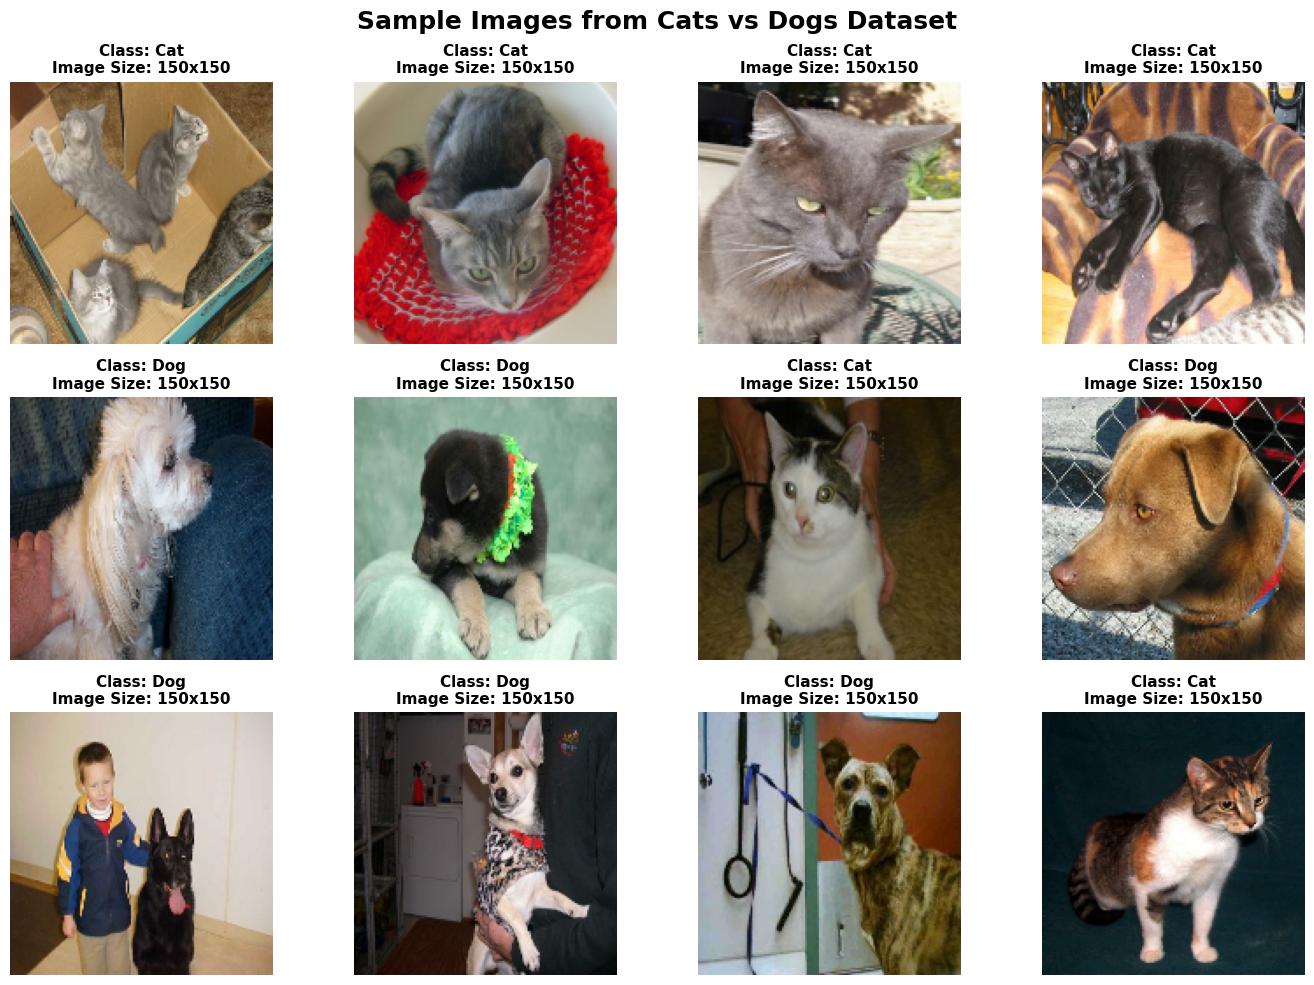

sample images saved successfully.


In [91]:
# ===============================
# Sample Image Visualization
# ===============================

plt.figure(figsize=(14,10))

for images, labels in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i + 1)

        img = images[i].numpy().astype("uint8")
        label = class_names[labels[i]]

        plt.imshow(img)
        plt.title(
            f"Class: {label}\nImage Size: {img.shape[0]}x{img.shape[1]}",
            fontsize=11,
            fontweight="bold"
        )
        plt.axis("off")

plt.suptitle(
    "Sample Images from Cats vs Dogs Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig("/kaggle/working/images/sample_images.png", 
            dpi=300, 
            bbox_inches="tight")

plt.show()

print("sample images saved successfully.")

# : Dataset Performance Optimization

In [61]:
# ===============================
# Dataset Performance Optimization
# ===============================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset Pipeline optimized successfully")

Dataset Pipeline optimized successfully


# Data Augmentation

In [62]:
# ===============================
# Data Augmentation
# ===============================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmention layer created successfully.")

Data augmention layer created successfully.


# CNN Model Build

In [63]:
# ===============================
# CNN Model Architecture
# ===============================

model = models.Sequential([

    #input layer
    layers.Input(shape=(150,150,3)),

    #data augmentation layer
    data_augmentation,

    #normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    #convolution block 1
    layers.Conv2D(32,(3,3), activation="relu"),
    layers.MaxPooling2D(),

    #convolution block 2
    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D(),

    #convolution block 3
    layers.Conv2D(128,(3,3),activation="relu"),

    #convolution block 4
    layers.Conv2D(256,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    #convert 2D feature maps into 1D vector
    layers.Flatten(),

    #fully connected layer
    layers.Dense(256, activation="relu"),

    #dropout layer to reduce overfitting
    layers.Dropout(0.5),

    #output layer
    layers.Dense(1, activation="sigmoid")
])

print("CNN model created successfully.")


CNN model created successfully.


In [64]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,166,145 (65.48 MB)

 Trainable params: 17,166,145 (65.48 MB)

 Non-trainable params: 0 (0.00 B)

# Compile Model

In [65]:
# ===============================
# Compile CNN Model
# ===============================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


# Training Callbacks

In [66]:
# ===============================
# Training Callbacks
# ===============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cat_dogs_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

print("Training callback created successfully.")

Training callback created successfully.


# Train Model

In [67]:
# ===============================
# Model Training
# ===============================

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

print("Model training completd successfully")

Epoch 1/3


Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


586/586 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5188 - loss: 0.7134

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


586/586 ━━━━━━━━━━━━━━━━━━━━ 47s 52ms/step - accuracy: 0.5352 - loss: 0.6907 - val_accuracy: 0.5762 - val_loss: 0.6801
Epoch 2/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.6154 - loss: 0.6507 - val_accuracy: 0.6731 - val_loss: 0.6053
Epoch 3/3
586/586 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.6813 - loss: 0.5945 - val_accuracy: 0.6778 - val_loss: 0.6246
Model training completd successfully


## Continue Model Training

In [69]:
# ===============================
# Continue Model Training
# ===============================

ADDITIONAL_EPOCHS = 12

history_more = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs=ADDITIONAL_EPOCHS,
    callbacks=[early_stop, checkpoint]
)

print("Additional training completed successfully.")

Epoch 1/12
586/586 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.6936 - loss: 0.5857 - val_accuracy: 0.7282 - val_loss: 0.5364
Epoch 2/12
586/586 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.7265 - loss: 0.5430 - val_accuracy: 0.7588 - val_loss: 0.4973
Epoch 3/12
586/586 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.7478 - loss: 0.5113 - val_accuracy: 0.7792 - val_loss: 0.4737
Epoch 4/12
586/586 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.7739 - loss: 0.4798 - val_accuracy: 0.7837 - val_loss: 0.4497
Epoch 5/12
586/586 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.7975 - loss: 0.4434 - val_accuracy: 0.8036 - val_loss: 0.4333
Epoch 6/12
586/586 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.8087 - loss: 0.4214 - val_accuracy: 0.8345 - val_loss: 0.3748
Epoch 7/12
586/586 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.8251 - loss: 0.3918 - val_accuracy: 0.8493 - val_loss: 0.3464
Epoch 8/12
586/586 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.8356 - loss: 0.3727 - 

### Final progess
Training Accuracy: 86.61%

Training Loss: 0.3093

Validation Accuracy: 84.84%

Validation Loss: 0.3704

In [90]:
# ===============================
# Create Images Folder
# ===============================

import os

os.makedirs("/kaggle/working/images", exist_ok=True)

print("Images folder created successfully.")

Images folder created successfully.


## Accuracy Graph

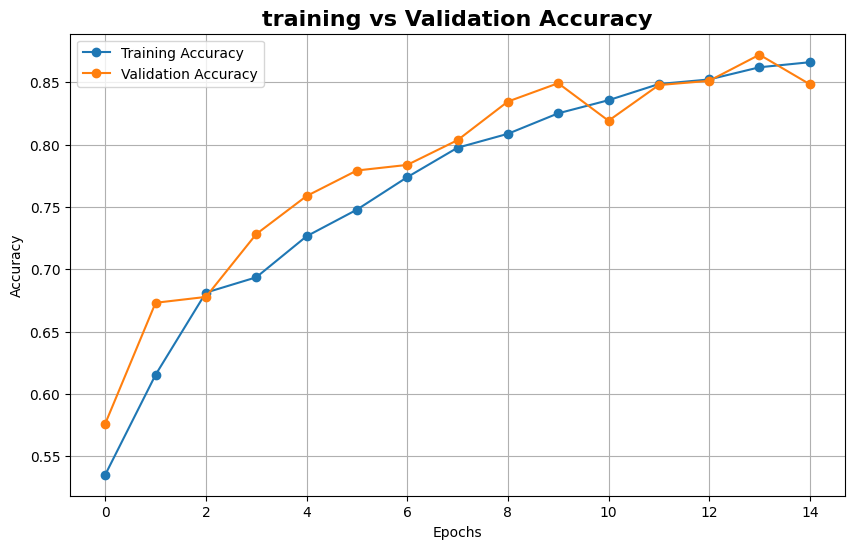

Accuracy graph saved successfully


In [92]:
# ===============================
# Accuracy Analysis
# ===============================

train_acc = history.history["accuracy"] + history_more.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_more.history["val_accuracy"]

plt.figure(figsize=(10,6))

plt.plot(train_acc, marker="o", label="Training Accuracy")
plt.plot(val_acc, marker="o",label="Validation Accuracy")

plt.title("training vs Validation Accuracy", 
          fontsize=16,
          fontweight="bold")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/images/accuracy_graph.png", 
            dpi=300,
            bbox_inches="tight")

plt.show()

print("Accuracy graph saved successfully")


### Accuracy Analysis
The training accuracy gradually improved from around 53% to 86%, while the validation accuracy improved from around 57% to 84%.

This shows that the model is learning meaningful visual features from the images such as face shape, ears, fur texture, and body patterns.

The model is not heavily overfitting.

## Loss Analysis

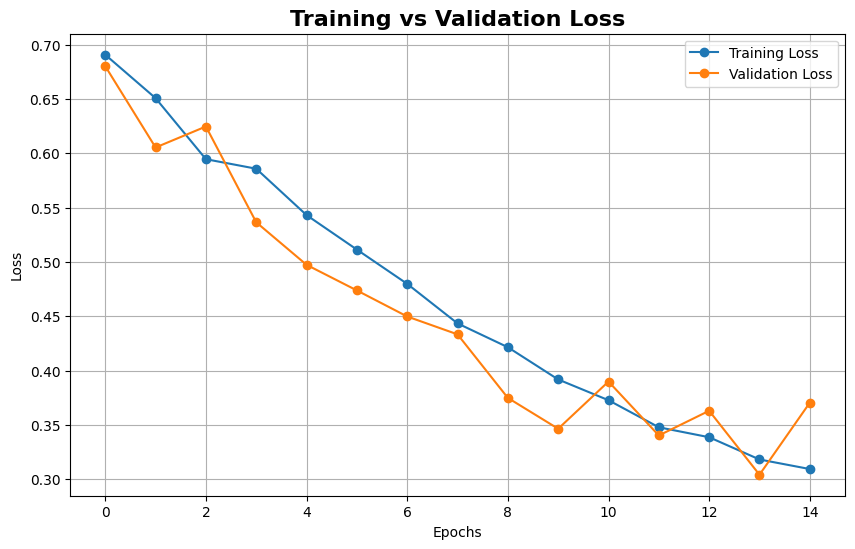

Loss graph saved successfully.


In [93]:
# ===============================
# Loss Analysis
# ===============================

train_loss = history.history["loss"] + history_more.history["loss"]
val_loss = history.history["val_loss"] + history_more.history["val_loss"]

plt.figure(figsize=(10,6))

plt.plot(train_loss,marker="o",label="Training Loss")
plt.plot(val_loss,marker="o",label="Validation Loss")

plt.title("Training vs Validation Loss",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/images/loss_graph.png", 
            dpi=300, 
            bbox_inches="tight")

plt.savefig("/kaggle/working/images/loss_graph.png", 
            dpi=300, 
            bbox_inches="tight")

plt.show()

print("Loss graph saved successfully.")

### Loss Analysis
The training loss continuously decreased during training, which indicates that the model was learning properly.

The model is performing well on unseen validation images.

A small fluctuation in validation loss near the final epochs is normal in deep learning projects.

## Final Model Evaluation

In [74]:
# ===============================
# Final Model Evaluation
# ===============================

val_loss, val_accuracy = model.evaluate(val_dataset)

print(f"Final Validation Loss : {val_loss: .4f}")
print(f"Final Validaton Accuracy :{val_accuracy:.4f}")


147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8721 - loss: 0.3041
Final Validation Loss :  0.3041
Final Validaton Accuracy :0.8721


## Final Model Evaluation Analysis

The trained CNN model achieved a final validation accuracy of **87.21%** and a validation loss of **0.3041**.

This means the model is able to correctly classify most unseen cat and dog images.the model is generalizing well and is not heavily overfitting.

The use of data augmentation, dropout, early stopping, and model checkpointing helped improve model performance and reduce overfitting.


## Confusion Matrix and Classification Report

Classification Report :
              precision    recall  f1-score   support

         Cat       0.85      0.89      0.87      2310
         Dog       0.89      0.85      0.87      2374

    accuracy                           0.87      4684
   macro avg       0.87      0.87      0.87      4684
weighted avg       0.87      0.87      0.87      4684



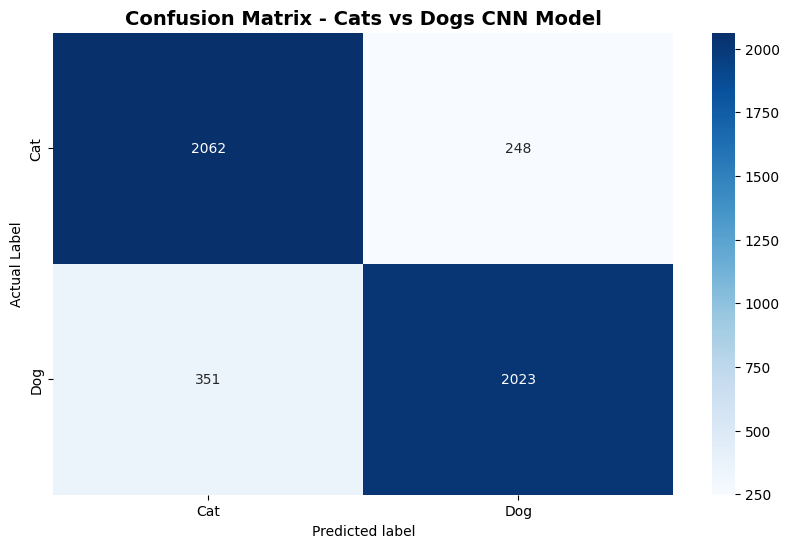

Confusion matrix saved successfully.


In [94]:
# ===============================
# Confusion Matrix & Classification Report
# ===============================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# store actual and predicted labels
y_true = []
y_pred = []

#loop thought validation dataset
for images,labels in val_dataset:
    predictions = model.predict(images,verbose=0)
    predicted_labels = (predictions > 0.5).astype("int32").flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

#confusion matrix
cm =confusion_matrix(y_true,y_pred)

print("Classification Report :")
print(classification_report(y_true,y_pred, target_names = class_names))

#plot confusion matrix
plt.figure(figsize=(10,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Cats vs Dogs CNN Model", 
          fontsize=14,
          fontweight="bold")

plt.xlabel("Predicted label")
plt.ylabel("Actual Label")

plt.savefig("/kaggle/working/images/confusion_matrix.png", 
            dpi=300, 
            bbox_inches="tight")

plt.show()

print("Confusion matrix saved successfully.")


In [95]:
# ===============================
# Check Saved Images
# ===============================

os.listdir("/kaggle/working/images")

['loss_graph.png',
 'accuracy_graph.png',
 'confusion_matrix.png',
 'sample_images.png']

## Confusion Matrix and Classification Report Analysis

The CNN model achieved an overall accuracy of **87%** on the validation dataset.

### Class-wise Performance

For the Cat class, the model achieved a precision of **0.85**, recall of **0.89**, and F1-score of **0.87**.

For the Dog class, the model achieved a precision of **0.89**, recall of **0.85**, and F1-score of **0.87**.

Both classes have the same F1-score of **0.87**, which shows that the model is performing in a balanced way for both Cat and Dog classification.

### Confusion Matrix Insight

The model correctly classified **2062 Cat images** and **2023 Dog images**.

However, the model misclassified **248 Cat images as Dog** and **351 Dog images as Cat**.

This indicates that the model performs well overall, but it makes slightly more mistakes when classifying some Dog images as Cat.

### Final Insight

The model shows strong performance for a custom CNN architecture with data augmentation, dropout, early stopping, and model checkpointing. The results are suitable for a strong deep learning portfolio project and can be further improved using transfer learning models such as MobileNetV2, VGG16, or EfficientNet.

## Single Image Prediction

In [84]:
# ===============================
# Single Image Prediction Function
# ===============================

def predict_image(image_path):
    #load image
    img = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    #convert image to array
    img_array = tf.keras.utils.img_to_array(img)
    
    #ADD batch dimension
    img_array = tf.expand_dims(img_array,0)

    #prediction
    prediction_score = model.predict(img_array,verbose=0)[0][0]

    #class maping
    cat_probability = 1 - prediction_score
    dog_probability = prediction_score
    
    if dog_probability >= 0.5:
        predicted_class = "Dog"
        confidence = dog_probability
    else:
        predicted_class ="Cat"
        confidence = cat_probability

    # show image with prediction
    plt.figure(figsize=(5,5))

    plt.imshow(img)
    plt.title(
        f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}",
        fontsize=14,
        fontweight="bold"
    )
    plt.axis("off")
    plt.show()

    print("Predicted score :",prediction_score)
    print(f"Cat Probability: {cat_probability:.2%}")
    print("Dog Probability:",predicted_class)
    print(f"Confidence score: {confidence:.2%}")
    
    return predicted_class,confidence


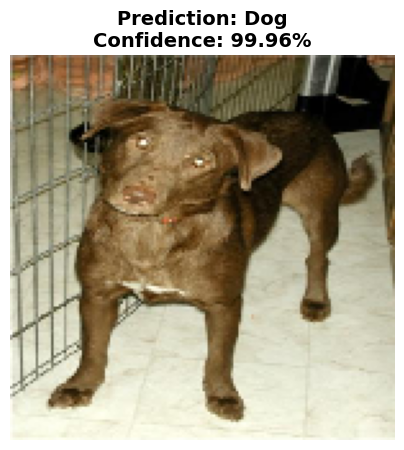

Predicted score : 0.9996244
Cat Probability: 0.04%
Dog Probability: Dog
Confidence score: 99.96%


('Dog', np.float32(0.9996244))

In [85]:
predict_image("/kaggle/input/datasets/sumitboyat/petimage/PetImages/Dog/1.jpg")

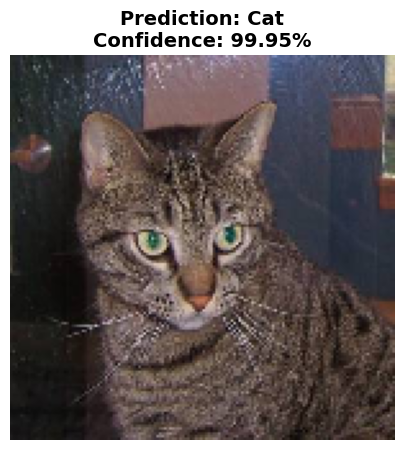

Predicted score : 0.0005030131
Cat Probability: 99.95%
Dog Probability: Cat
Confidence score: 99.95%


('Cat', np.float32(0.999497))

In [86]:
predict_image("/kaggle/input/datasets/sumitboyat/petimage/PetImages/Cat/1.jpg")

## Single Image Prediction Analysis

The trained CNN model was tested on individual Cat and Dog images.

The model correctly predicted both sample images with high confidence, showing that it can classify unseen images at the single-image level.

This step demonstrates how the trained model can be used in a real-world application where a user uploads one image and the system predicts whether it is a Cat or Dog.



In [96]:
import shutil

shutil.make_archive(
    "/kaggle/working/project_images",
    "zip",
    "/kaggle/working/images"
)

print("project_images.zip created successfully.")

project_images.zip created successfully.


# Save Final Model

In [87]:
# ===============================
# Save Final Model
# ===============================

model.save("cats_vs_dogs_custom_cnn_model.keras")

print("Final Custom CNN model saved successfully.")

Final Custom CNN model saved successfully.


## Load Saved Model

In [88]:
# ===============================
# Load Saved Model
# ===============================

loaded_model = tf.keras.models.load_model("cats_vs_dogs_custom_cnn_model.keras")

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [89]:
# ===============================
# Verify Loaded Model Performance
# ===============================

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_dataset)

print(f"Loaded Model Validation Loss: {loaded_loss:.4f}")
print(f"Loaded Model Validation Accuracy: {loaded_accuracy:.4f}")

147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8721 - loss: 0.3041
Loaded Model Validation Loss: 0.3041
Loaded Model Validation Accuracy: 0.8721


## Final Project Analysis

The custom CNN model was successfully trained and evaluated for Cats vs Dogs image classification.

The final saved model achieved a validation accuracy of **87.21%** and a validation loss of **0.3041** on unseen validation data.

The model was also saved and loaded again successfully. After loading, the model produced the same validation accuracy, which confirms that the trained model is reusable and ready for future prediction or deployment.

### Key Techniques Used

- Image preprocessing
- Data augmentation
- CNN architecture
- Dropout regularization
- EarlyStopping
- ModelCheckpoint
- Accuracy and loss visualization
- Confusion matrix
- Classification report
- Single image prediction
- Model saving and loading

### Final Business Conclusion

This project demonstrates an end-to-end deep learning image classification pipeline. The model can classify Cat and Dog images with good accuracy and can be used as a base model for real-world applications such as pet identification systems, animal shelter image tagging, and automated image labeling.

The model performance can be further improved in the future using transfer learning models such as MobileNetV2, VGG16, ResNet50, or EfficientNet.